<a href="https://colab.research.google.com/github/nehashah2898/AIPI590/blob/main/mechanistic_interp_starter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[![Open In Collab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AIPI-590-XAI/Duke-AI-XAI/blob/main/assignments/mechanistic_interp_starter.ipynb)

# Example Notebook for Mechanistic Interpretability Assignment

Use this notebook as starter code for your Mechanistic Interpretability assignment. You should build your own tiny model on a tiny problem.

This could be:

* Counting 1s in binary strings (like shown here)

* Reversing short character sequences

* XOR or parity classification

* Or any other toy task you design yourself!


**Methods shown in this notebook:**
* Training a small MLP to solve a regression task (predicting the count of 1s)

* Visualizing hidden layer activations averaged by input type (number of 1s)

* Performing neuron ablation (zeroing hidden neurons) to test their functional role

* Visualizing the effect of individual neurons on the model’s output

**Additional methods you can try for your problem:**
* Inspecting activations for specific inputs (not just averaged)

* Plotting neuron selectivity curves (activation vs. input feature)

* Visualizing weight matrices to find interpretable patterns

* Perturbing inputs (e.g., flipping bits) to observe model robustness

* Comparing intermediate representations across training checkpoints

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random
import numpy as np

### Data Generation

In [2]:
def generate_binary_data(n_samples=10000, seq_length=8):
    X = []
    y = []
    for _ in range(n_samples):
        binary_str = [random.choice([0, 1]) for _ in range(seq_length)]
        label = sum(binary_str)
        X.append(binary_str)
        y.append(label)
    return torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.long)

seq_length = 8
n_classes = seq_length + 1
X_train, y_train = generate_binary_data(2000, seq_length)
X_val, y_val = generate_binary_data(500, seq_length)

### Build a Tiny MLP (multilayer perceptron) Model

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Updated Model for Regression
class CountingMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 1)  # Output is a single scalar

    def forward(self, x):
        h = F.relu(self.fc1(x))
        out = self.fc2(h)
        return out, h  # for interpretability

# Instantiate model
model = CountingMLP(input_dim=seq_length, hidden_dim=10)
print(model)

# Convert targets to float (regression labels)
y_train_reg = y_train.float().unsqueeze(1)
y_val_reg = y_val.float().unsqueeze(1)

# Training loop with MSE loss
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.MSELoss()

losses = []
for epoch in range(100):
    model.train()
    out, _ = model(X_train)
    loss = criterion(out, y_train_reg)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

print("Final training loss:", losses[-1])

# Evaluation: Mean Absolute Error + Rounded Accuracy
model.eval()
with torch.no_grad():
    preds, _ = model(X_val)
    mae = torch.abs(preds - y_val_reg).mean().item()
    rounded_preds = torch.round(preds).squeeze().long()
    accuracy = (rounded_preds == y_val).float().mean().item()

print(f"Validation MAE: {mae:.2f}")
print(f"Rounded Accuracy: {accuracy:.2f}")


CountingMLP(
  (fc1): Linear(in_features=8, out_features=10, bias=True)
  (fc2): Linear(in_features=10, out_features=1, bias=True)
)
Final training loss: 0.16046546399593353
Validation MAE: 0.31
Rounded Accuracy: 0.82


### Print Activations of a sample input

In [4]:
with torch.no_grad():
    sample_input = torch.tensor([[1, 0, 1, 0, 1, 1, 0, 0]], dtype=torch.float32)
    logits, hidden = model(sample_input)

print(f"Sample Input: {sample_input}")
print(f"Hidden Layer Activations: {hidden}")
print(f"Output Logits: {logits}")
rounded = round(logits.item())
print(f"Rounded Prediction: {rounded}")


Sample Input: tensor([[1., 0., 1., 0., 1., 1., 0., 0.]])
Hidden Layer Activations: tensor([[2.2186, 0.0000, 1.6536, 1.9963, 0.0000, 1.1557, 0.0000, 1.5320, 0.0000,
         1.0374]])
Output Logits: tensor([[4.1253]])
Rounded Prediction: 4


### Plot hidden activations across different numbers of 1s as input

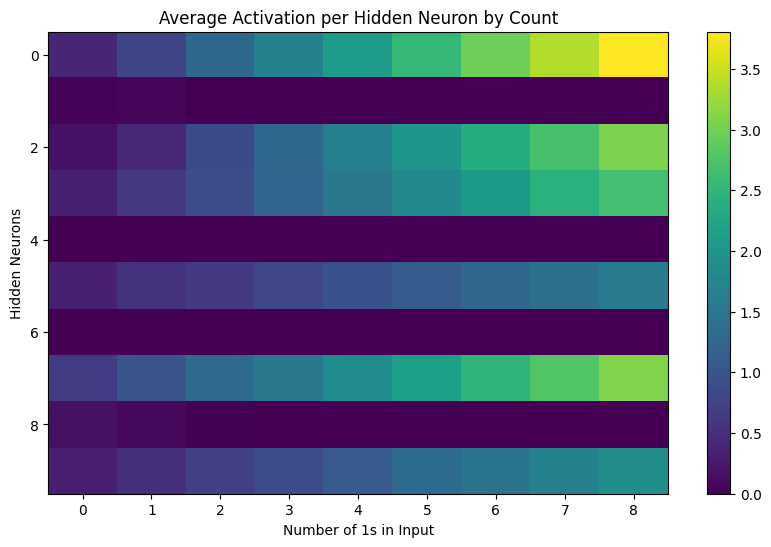

In [5]:
counts = list(range(n_classes))
avg_activations = torch.zeros((n_classes, 10))

for c in counts:
    class_inputs = X_val[y_val == c]
    if class_inputs.shape[0] > 0:
        _, h = model(class_inputs)
        avg_activations[c] = h.mean(dim=0)

plt.figure(figsize=(10, 6))
activations_np = avg_activations.T.detach().numpy()
plt.imshow(activations_np, aspect='auto', cmap='viridis')
plt.xlabel("Number of 1s in Input")
plt.ylabel("Hidden Neurons")
plt.title("Average Activation per Hidden Neuron by Count")
plt.colorbar()
plt.show()

#### **What does this plot show us?**

##### *Neuron Specialization*
Look for rows (neurons) that are brightest at specific counts.

If a neuron appears consistently dark, that could mean it is unused or suppressed.

##### *Monotonic Trends*
If neurons show a gradual increase in activation with count — they may be learning a linear or thresholded count pattern.

That’s a great example of linearly increasing features often discussed in mechanistic interpretability (e.g. linear probe-ability).

##### *Redundant or Silent Units*
Some neurons may appear flatlined which possibly means they are unused due to redundancy. *What happens if you remove the neuron entirely?*

##### *Activation Superposition*
Some neurons activate across a range of counts, possibly blending multiple input features — this ties into superposition theory (see: Toy Models of Superposition)

_____________________

### Neuron Ablation (single neuron)

In [6]:
# Sample input to test
test_input = torch.tensor([[1, 0, 1, 1, 0, 0, 1, 0]], dtype=torch.float32)  # Example: 4 ones
true_count = int(test_input.sum().item())

# Baseline prediction
model.eval()
with torch.no_grad():
    baseline_output, _ = model(test_input)
    baseline_pred = baseline_output.item()

# Zero out one neuron in the hidden layer (e.g., neuron 3)
neuron_to_zero = 3

# Manually run forward pass with neuron ablated
with torch.no_grad():
    h = F.relu(model.fc1(test_input))
    h[:, neuron_to_zero] = 0  # zeroing neuron
    modified_output = model.fc2(h)
    modified_pred = modified_output.item()


print(f"True count: {true_count}")
print(f"Prediction (normal): {baseline_pred:.2f}")
print(f"Prediction (with neuron {neuron_to_zero} zeroed): {modified_pred:.2f}")

delta = modified_pred - baseline_pred
if delta > 0:
    print(f"➕ Prediction increased by {delta:.2f}")
elif delta < 0:
    print(f"➖ Prediction decreased by {abs(delta):.2f}")
else:
    print("⚖️ No change in prediction")


True count: 4
Prediction (normal): 3.97
Prediction (with neuron 3 zeroed): 3.37
➖ Prediction decreased by 0.60


#### **What does the ablation tell us?**

If the prediction changes significantly after zeroing out a neuron, that neuron likely plays an important functional role in the model’s decision!

### Neuron Ablation (sweep of neurons)

🧾 True count: 4, Baseline prediction: 3.97


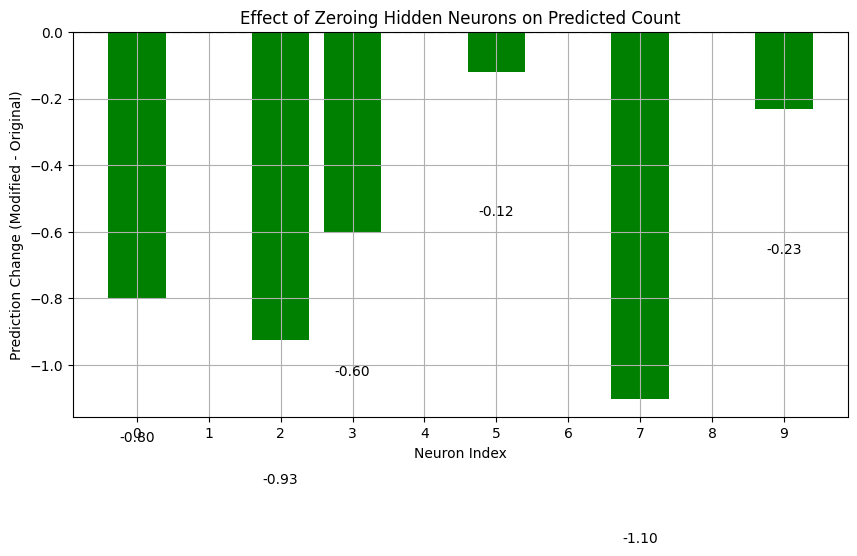

Neuron 0 → Prediction decreased by 0.80
Neuron 2 → Prediction decreased by 0.93
Neuron 3 → Prediction decreased by 0.60
Neuron 5 → Prediction decreased by 0.12
Neuron 7 → Prediction decreased by 1.10
Neuron 9 → Prediction decreased by 0.23


In [7]:
# Sample input to test
test_input = torch.tensor([[1, 0, 1, 1, 0, 0, 1, 0]], dtype=torch.float32)
true_count = int(test_input.sum().item())

# Baseline prediction
model.eval()
with torch.no_grad():
    baseline_output, _ = model(test_input)
    baseline_pred = baseline_output.item()

print(f"🧾 True count: {true_count}, Baseline prediction: {baseline_pred:.2f}")

# Sweep: get signed change in scalar prediction
neuron_indices = list(range(model.fc1.out_features))
signed_deltas = []

for i in neuron_indices:
    with torch.no_grad():
        h = F.relu(model.fc1(test_input))
        h[:, i] = 0  # zero out neuron i
        mod_output = model.fc2(h)
        mod_pred = mod_output.item()
        signed_deltas.append(mod_pred - baseline_pred)

# Plotting signed prediction change per neuron
plt.figure(figsize=(10, 5))
colors = ['green' if d < 0 else 'red' if d > 0 else 'gray' for d in signed_deltas]

plt.bar(neuron_indices, signed_deltas, color=colors)
plt.axhline(0, color='black', linestyle='--')
plt.xticks(neuron_indices)
plt.xlabel("Neuron Index")
plt.ylabel("Prediction Change (Modified - Original)")
plt.title("Effect of Zeroing Hidden Neurons on Predicted Count")
plt.grid(True)

# Annotatation
for i, d in enumerate(signed_deltas):
    if abs(d) > 1e-3:
        plt.text(i, d + (0.2 if d > 0 else -0.4), f"{d:+.2f}",
                 ha='center', va='bottom' if d > 0 else 'top')

plt.show()

# Summary
for i, d in enumerate(signed_deltas):
    if abs(d) > 1e-3:
        direction = "increased" if d > 0 else "decreased"
        print(f"Neuron {i} → Prediction {direction} by {abs(d):.2f}")


#### **What does the sweep of neuron ablations tell us?**

Which neurons had the most impact on predictions?

Are there redundant neurons (zeroing them causes no change)?

## Part 1 — Setup
Dataset = all 64 binary strings of length 6. Label odd parity as 1.
Model = one‑hidden‑layer MLP (hidden=32, **tanh**). Optimizer = Adam.

Train accuracy: 100.00%


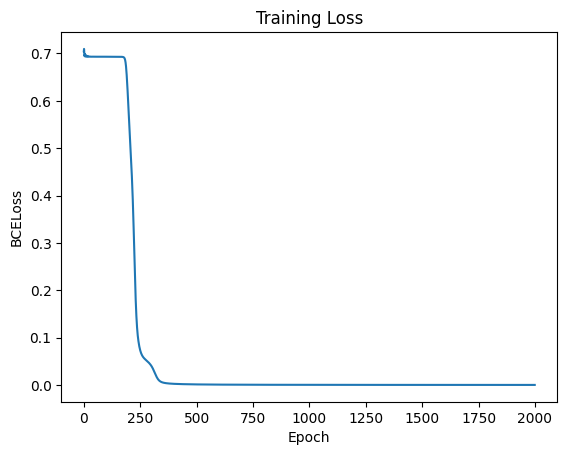

In [8]:

import torch, torch.nn as nn, torch.optim as optim
import itertools, numpy as np, matplotlib.pyplot as plt

torch.manual_seed(1)
np.random.seed(1)

n_bits = 6
X = np.array(list(itertools.product([0,1], repeat=n_bits)), dtype=np.float32)
y = (X.sum(axis=1) % 2).astype(np.float32)
X_tensor = torch.from_numpy(X)
y_tensor = torch.from_numpy(y).view(-1,1)

class TinyParityNet(nn.Module):
    def __init__(self, in_dim=6, hidden=32):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, hidden, bias=True)
        self.act = nn.Tanh()
        self.fc2 = nn.Linear(hidden, 1, bias=True)
    def forward(self, x):
        h = self.act(self.fc1(x))
        out = torch.sigmoid(self.fc2(h))
        return out, h

model = TinyParityNet(6, hidden=32)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.03)

losses = []
for epoch in range(2000):
    optimizer.zero_grad()
    out, _ = model(X_tensor)
    loss = criterion(out, y_tensor)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

with torch.no_grad():
    preds = (model(X_tensor)[0] > 0.5).float()
    acc = (preds.eq(y_tensor).float().mean().item())

print(f"Train accuracy: {acc*100:.2f}%")

plt.figure()
plt.plot(losses)
plt.xlabel("Epoch"); plt.ylabel("BCELoss"); plt.title("Training Loss")
plt.show()


## Part 2 — Explore
We:
1. Plot all input→hidden weights
2. Select the hidden neuron with the **most uniform** input weights (lowest std dev)
3. Plot its activation vs. **Hamming weight** (# of ones)
4. Perform single‑unit ablations to see accuracy impact (expect small drops due to redundancy)

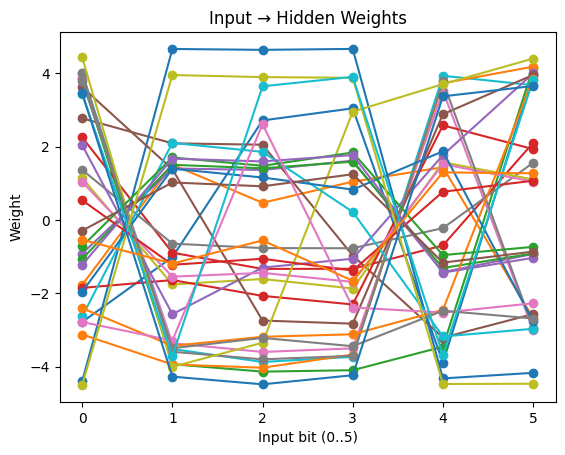

Candidate neuron: h25 (lowest input-weight std = 0.957)
h25 bias b1 = 0.278, output weight W2 = -0.299


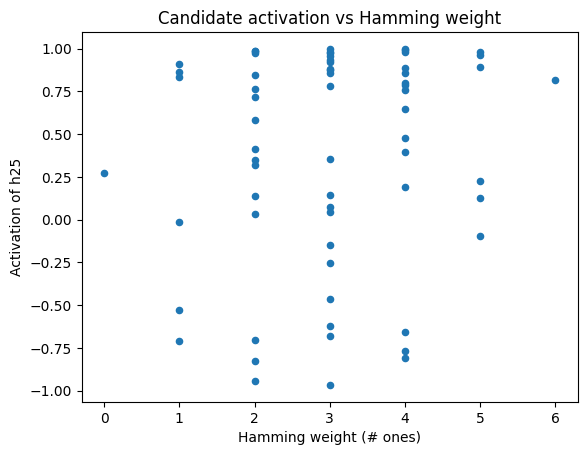

Base acc = 100.00%. Largest single‑unit ablation drop: h0 → 0.00%


In [9]:

import numpy as np, matplotlib.pyplot as plt, torch

with torch.no_grad():
    out, H = model(X_tensor)
H_np = H.numpy()
W1 = model.fc1.weight.detach().numpy()
b1 = model.fc1.bias.detach().numpy()
W2 = model.fc2.weight.detach().numpy().reshape(-1)

hidden = W1.shape[0]

plt.figure()
for i in range(hidden):
    plt.plot(W1[i], marker='o')
plt.xlabel('Input bit (0..5)'); plt.ylabel('Weight')
plt.title('Input → Hidden Weights')
plt.show()

stds = np.std(W1, axis=1)
candidate = int(np.argmin(stds))
print(f"Candidate neuron: h{candidate} (lowest input-weight std = {stds[candidate]:.3f})")
print(f"h{candidate} bias b1 = {b1[candidate]:.3f}, output weight W2 = {W2[candidate]:.3f}")

hamming = X.sum(axis=1); act_c = H_np[:, candidate]
plt.figure()
plt.scatter(hamming, act_c, s=20)
plt.xlabel('Hamming weight (# ones)'); plt.ylabel(f'Activation of h{candidate}')
plt.title('Candidate activation vs Hamming weight')
plt.show()

def eval_with_ablation(k=None):
    with torch.no_grad():
        z = model.act(model.fc1(X_tensor))
        if k is not None:
            z[:, k] = 0.0
        out = torch.sigmoid(model.fc2(z))
        return ((out > 0.5).float().eq(y_tensor).float().mean().item())

base_acc = eval_with_ablation(None)
drops = [base_acc - eval_with_ablation(i) for i in range(hidden)]
top = int(np.argmax(drops))
print(f"Base acc = {base_acc*100:.2f}%. Largest single‑unit ablation drop: h{top} → {drops[top]*100:.2f}%")


## Part 3
Hypothesis: The selected hidden unit implements a soft Hamming‑weight detector by assigning roughly uniform weights to all input bits. Its activation increases with the of ones, and the output layer uses this (and other helper units) to decide odd vs even parity.


Result: (i) low variance in incoming weights, (ii) monotonic activation w.r.t. Hamming weight, (iii) ablation shows some dependence—though small drop indicates redundancy across units.

## Part 4
- Probing tiny networks with weight statistics, activation plots, and ablations is enough to form a concrete mechanistic story.
- Roles are distributed; no single neuron is strictly necessary.
-  Swap in a tiny RNN to find a "toggle" neuron that flips state each time it sees a 1, which is another mechanistic solution to parity.